In [1]:
#import labraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
import sqlite3

In [3]:
#import database


In [4]:
conn = sqlite3.connect(r"D:\Data Analytics\Churn_analysis\customer_churn.db")

sql_query = """

        SELECT name
        FROM sqlite_master
        WHERE type = 'table';
"""
tables = pd.read_sql(sql_query, conn)

#create dataframe for each table
for table_name in tables ['name']:
    df = pd.read_sql(f"select * from {table_name}" , conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [5]:
#print table name and column name
conn = sqlite3.connect(r"D:\Data Analytics\Churn_analysis\customer_churn.db")

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}:")
    #get column information
    columns_query = f"PRAGMA table_info({table_name});"                #pragma is a command which is use to take table information we aslo called it meta 
    columns = pd.read_sql(columns_query, conn)
    print("Colunms:")
    print(columns["name"].tolist())

conn.close()


Table Name: db_customer:
Colunms:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription:
Colunms:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support:
Colunms:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [6]:
#Data Cleaning

In [7]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [8]:
df_db_customer.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [9]:
#a.rename col - name
#b.drop columns - interest and pincode
#c.change data type - dob
#d. Data standarization -Gender
#E.  fix missing values - country
 

In [10]:
#a.rename col - name
df_db_customer.rename(columns ={'name' : 'customer name'} , inplace = True)
df_db_customer

,customerid,customer name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [11]:
#b.drop columns - interest and pincode

# by using index value or .drop 

#df_db_customer.drop(df_db_customer.columns[-2:] , axis = 1, )   use these either than 6: for drop last tow columns
#df_db_customer.drop(df_db_customer.columns[6:] , axis = 1, )

#easy way ---->>>
df_db_customer.drop(columns = ['interests', 'pincode'], inplace= True)
df_db_customer


,customerid,customer name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [12]:
#c.change data type - dob
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [13]:
# to change datatype -dob

#pd.to_datetime(df_db_customer['dob'])

#store value without inplace 
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [14]:
#d. Data standarization -Gender
df_db_customer['gender'].unique()
#df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})  # store without inplace

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [15]:
#E.  fix missing values - country


#df_db_customer['country'].isna()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [16]:
# df_db_customer['country'].fillna(0)           optional option to replace missing value when we have to work with these data

In [17]:
# country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))   
#df_db_customer[['country', 'state']]

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: object

In [18]:
#df_db_customer['country'].isna()


In [19]:
#--------> sorted there is a no null value

In [20]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,None,None,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,None,None,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,None,None,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,None,None,13.99,790,47


In [21]:
df_db_subscription.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [22]:
date_col = ['subscription_start_date', 'renewal_date','cancellation_date']	
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [23]:
df_db_subscription.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [24]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [25]:
df_db_support.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [26]:
df_db_support.drop(columns=['col_1', 'comment'] ,inplace=True)

In [27]:
df_db_support['complaint_date'] =pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [28]:
                                                        #FEATURE ENGINEERING AND DATA ANALYSIS

In [29]:
# create new column using existing col - churn flag 
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)


In [30]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [31]:
# merge tables 
# first fix support table duplicates then merge
df  = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left') )

In [32]:
df_db_subscription.shape

(21, 12)

In [33]:
df.shape

(23, 20)

In [34]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [35]:
 df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [36]:
#create a column df_db_support['complaint_count'] to store value 
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')


In [37]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [38]:
df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [39]:
#store these data 
df_db_support =df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')


In [40]:
df_db_support['customerid'].size

7

In [41]:
# merge df

df  = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left') )

In [42]:
df.shape

(21, 21)

In [43]:
 df.to_csv('exported_churn_data.csv' , index = False)

In [44]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [45]:
df['churn_flag'].mean()

np.float64(0.2857142857142857)

In [46]:
#Churn Rate

churn_rate =  df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")


Churn Rate =  28.57 %


In [47]:
#Retention rate 

In [48]:
retention_rate = 100 - churn_rate
print("Retention_rate = ", round(retention_rate,2), "%")


Retention_rate =  71.43 %


In [49]:
# 3 . Churn by Plan type

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean()

In [50]:
# basic is  high so find out why Basic max

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print( churn_by_plan )


  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [51]:
#4 a.churn_by state + sume(revenue) & count of userss
#4 b.churn_by subsription type + sume(revenue) & count of userss

In [52]:
#4 a.churn_by state + sume(revenue) & count of userss
churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: x.mean() * 100),
          total_monthly_charges=('monthly_charges', 'sum'),
          total_cltv=('cltv', 'sum'),
          total_users=('customerid', 'count')
      )
      .reset_index()
)

churn_by_state['churn_rate_pct'] = churn_by_state['churn_rate_pct'].round(2)

churn_by_state


,state,churn_rate_pct,total_monthly_charges,total_cltv,total_users
0,Delhi,25.00,52.96,1765,4
1,Karnataka,100.00,20.98,1420,2
2,Kathmandu,0.00,20.98,575,2
3,Maharashtra,0.00,50.97,3027,3
4,Meghalaya,66.67,42.97,940,3
5,Nagaland,0.00,22.99,1725,1
6,Rajasthan,0.00,36.98,2680,2
7,Telangana,50.00,30.98,1022,2
8,Uttar Pradesh,0.00,115.98,4140,2


In [53]:
#4 b.churn_by subsription type + sume(revenue) & count of userss


churn_by_subcription  = (
    df.groupby('subscription_type')
    .agg(
        total_revenue = ('monthly_charges', 'sum'),
        total_users = ('customerid', 'count')
    )
    .reset_index()
)
churn_by_subcription

,subscription_type,total_revenue,total_users
0,Organic,145.91,9
1,Paid,174.94,6
2,Refferal,74.94,6


In [54]:
# 5.Average Revenue per user

arpu =  df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [55]:
# Average customer tenure
# 6. count of days users has our  service : concellation date else current date

# why matter : Retention Insight: Longer tenure means customers are sticking around, which usually signals satisfaction and value.

# Revenue Forecasting: Helps estimate customer lifetime value (CLV).

# Strategy Evaluation: If tenure increases after a new loyalty program, you know it’s working.

# Segmentation: Different customer groups may have different tenures, revealing where churn is concentrated.


In [56]:
# Average customer tenure
# 6. count of days users has our  service : concellation date else current date

pd.Timestamp.today()

Timestamp('2026-08-16 00:32:35.540988')

In [57]:
# calculate customer age  homework

In [58]:
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days

)
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = " , round(avg_tenure), 0 )



Avg Tenure (Days) =  1518 0


In [59]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [60]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1980.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0


In [61]:
# Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag'] == 1 , 'monthly_charges'].sum()
print("Revenue at risk  (Rs Lakhs) =", revenue_at_risk)


Revenue at risk  (Rs Lakhs) = 73.94


In [62]:
#8. Escalation Rate
df['escalations'].value_counts()

escalations
Y    4
N    3
Name: count, dtype: int64

In [63]:
escalation_rate = (
   (df['escalations']== 'Y').mean() * 100
)
print("Escalation Rate = " , round(escalation_rate, 2), "%")

Escalation Rate =  19.05 %


In [64]:
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()

print("Avg Complaints Per User = " , round(avg_complaints,2))

Avg Complaints Per User =  0.43


In [65]:
# 11. Correlation Escalation vs Churn
df['escalations'].value_counts()


escalations
Y    4
N    3
Name: count, dtype: int64

In [66]:
df[['customerid', 'escalations', 'churn_flag']].dropna()

,customerid,escalations,churn_flag
1,0003-MKNFE,Y,1
4,0013-EXCHZ,Y,1
5,0013-MHZWF,N,0
6,0013-SMEOE,N,1
11,0017-IUDMW,Y,1
13,0019-EFAEP,Y,1
18,0022-TCJCI,N,1


In [67]:
df['escalations'] = np.where(df['escalations'] == 'Y' , 1, 0) # encoding string to int type
corr_df = df[['escalations' , 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag']) 

print("Correlation between escalation vs churn is = ", round(correlation,2))


Correlation between escalation vs churn is =  0.77


In [68]:
# 11 . Churn risk create a column using existing col
condition = [
    df['churn_score'] < 50,
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    df['churn_score'] >= 70
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(
    condition,
    choices,
    default='unknown'
)


In [69]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1980.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1365.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2655.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


# Visualization using Matplotlib


In [70]:
df_visual  = df.copy()

In [71]:
# 4.1 Monthly Churn Trend ( Time series KPI) 


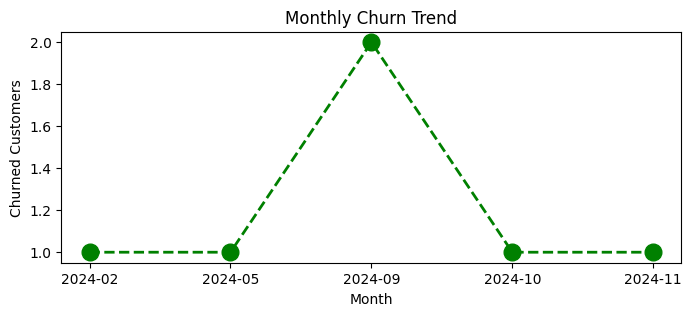

In [72]:
df_visual['cancellation_Month'] = df_visual['cancellation_date'].dt.to_period('M')

Churn_Trend = df_visual[df_visual['churn_flag'] == 1 ].groupby('cancellation_Month').size()

# PLOT
plt.figure(figsize=(8,3))
plt.plot(Churn_Trend.index.astype(str), Churn_Trend.values,color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

# plt.plot()

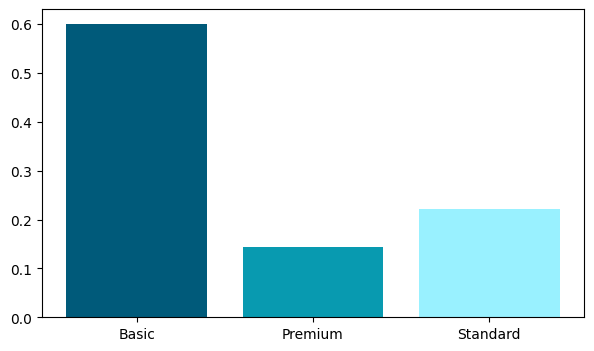

In [73]:
# 4.2 churn by plan type
churn_plan =df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['#005A7A', '#089AB0', '#99F1FF']      #for manually colour pass
# colors =  plt.cm.Set2(np.linspace(0,1, len(churn_plan)))    # for randomly colour update
plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values,color = colors)
plt.show()





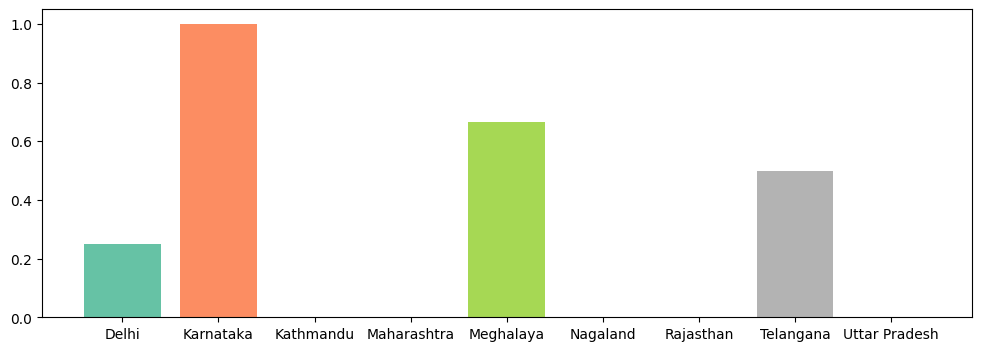

In [74]:
# 4.3 Churn by states

churn_plan =df_visual.groupby('state')['churn_flag'].mean()

# colors = ['#005A7A', '#089AB0', '#99F1FF']      #for manually colour pass
colors =  plt.cm.Set2(np.linspace(0,1, len(churn_plan)))    # for randomly colour update
plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values,color = colors)
plt.show()



# Visualization using Seaborn

In [75]:
# Heatmap (correlation matrix)

# Heatmap म्हणजे values ला color intensity वापरून दाखवणारा chart.
# Churn Analysis मध्ये तो mainly correlation between numerical columns पाहण्यासाठी useful आहे.


# ------- from defination we have to find corr between features but before these we have to convert str to numeri 

# encoding
df_visual.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_Month'],
      dtype='object')

In [76]:
# df_encoded = 
df_visual[[ 'plan_type', 'contract_type','churn_score','escalations','churn_flag','churn_risk', ]].head()

,plan_type,contract_type,churn_score,escalations,churn_flag,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [77]:
import warnings
warnings.filterwarnings("ignore")

In [78]:
# incorrect method of encoding  - as numbers are not assinged besed on prio

df_encoded = df_visual[[ 'plan_type', 'contract_type','churn_score','escalations','churn_flag','churn_risk', ]]

categorials_cols = ['plan_type', 'contract_type','churn_risk']

for col in categorials_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [79]:
# converted string to numeric
df_visual[[ 'plan_type', 'contract_type','churn_score','escalations','churn_flag','churn_risk', ]].head()

,plan_type,contract_type,churn_score,escalations,churn_flag,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [80]:
df_encoded.head()

,plan_type,contract_type,churn_score,escalations,churn_flag,churn_risk
0,2,0,12,0,0,1
1,1,0,91,1,1,0
2,0,1,34,0,0,1
3,1,0,8,0,0,1
4,2,1,88,1,1,0


<Axes: >

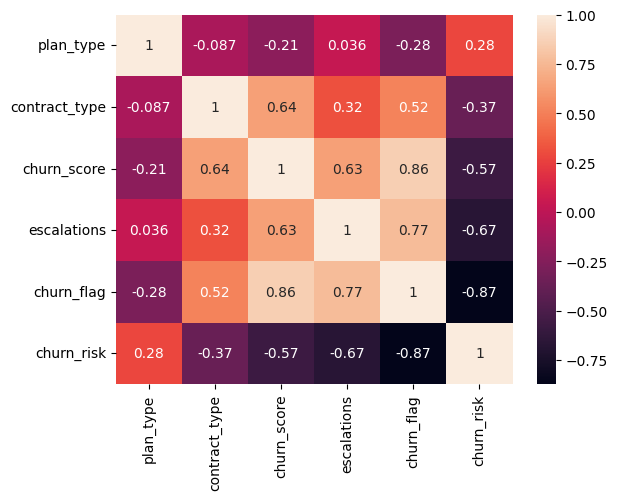

In [81]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [82]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [83]:
# correct method of encoding  -based on prio

df_encoded = df_visual[[ 'plan_type', 'contract_type','churn_score','escalations','churn_flag','churn_risk', ]]



order_mapping= {'plan_type' : ['Basic','Standard','Premium'], 
                 'contract_type' : ['Monthly','Annual'],
                 'churn_risk' : ['low' , 'med' , 'high']
                }

for col, order in order_mapping.items():
    df_encoded[col] =pd.Categorical( df_encoded[col].astype('category'), categories=order , ordered = True).codes

In [84]:
df_visual[[ 'plan_type', 'contract_type','churn_score','escalations','churn_flag','churn_risk', ]].head()


,plan_type,contract_type,churn_score,escalations,churn_flag,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [85]:
df_encoded.head()

,plan_type,contract_type,churn_score,escalations,churn_flag,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

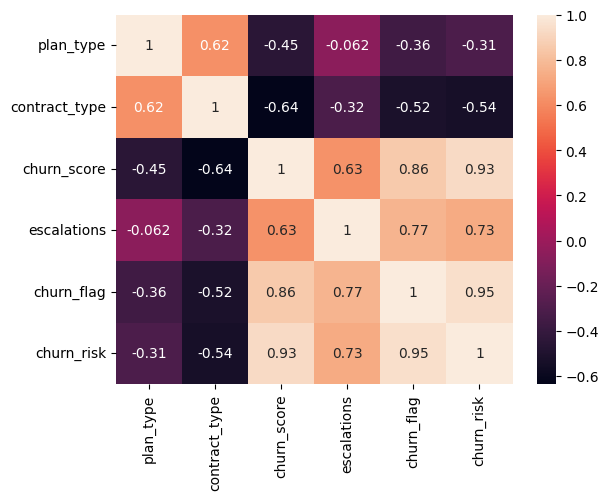

In [86]:
sns.heatmap(df_encoded.corr(), annot=True)


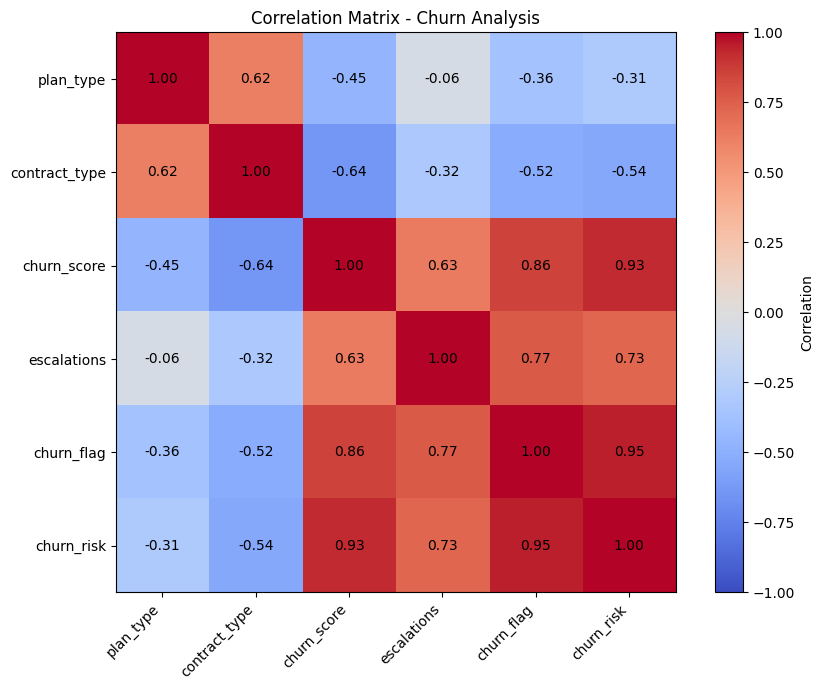

In [87]:
# using matplotLIb

# 1. Select required columns
df_encoded = df_visual[
    [
        'plan_type',
        'contract_type',
        'churn_score',
        'escalations',
        'churn_flag',
        'churn_risk'
    ]
].copy()


# 2. Define the correct order for categorical columns
order_mapping = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
}


# 3. Convert categorical columns into ordered numerical values
for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes


# 4. Convert escalations Y/N into 1/0 if required
if df_encoded['escalations'].dtype == 'object':
    df_encoded['escalations'] = df_encoded['escalations'].map({
        'Y': 1,
        'N': 0
    })


# 5. Create correlation matrix
corr_matrix = df_encoded.corr()


# 6. Create heatmap using Matplotlib
plt.figure(figsize=(9, 7))

plt.imshow(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

# X-axis labels
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha='right'
)

# Y-axis labels
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)


# 7. Display correlation values inside cells
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f'{corr_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )


# 8. Add color bar
plt.colorbar(label='Correlation')


# 9. Title
plt.title('Correlation Matrix - Churn Analysis')

plt.tight_layout()
plt.show()

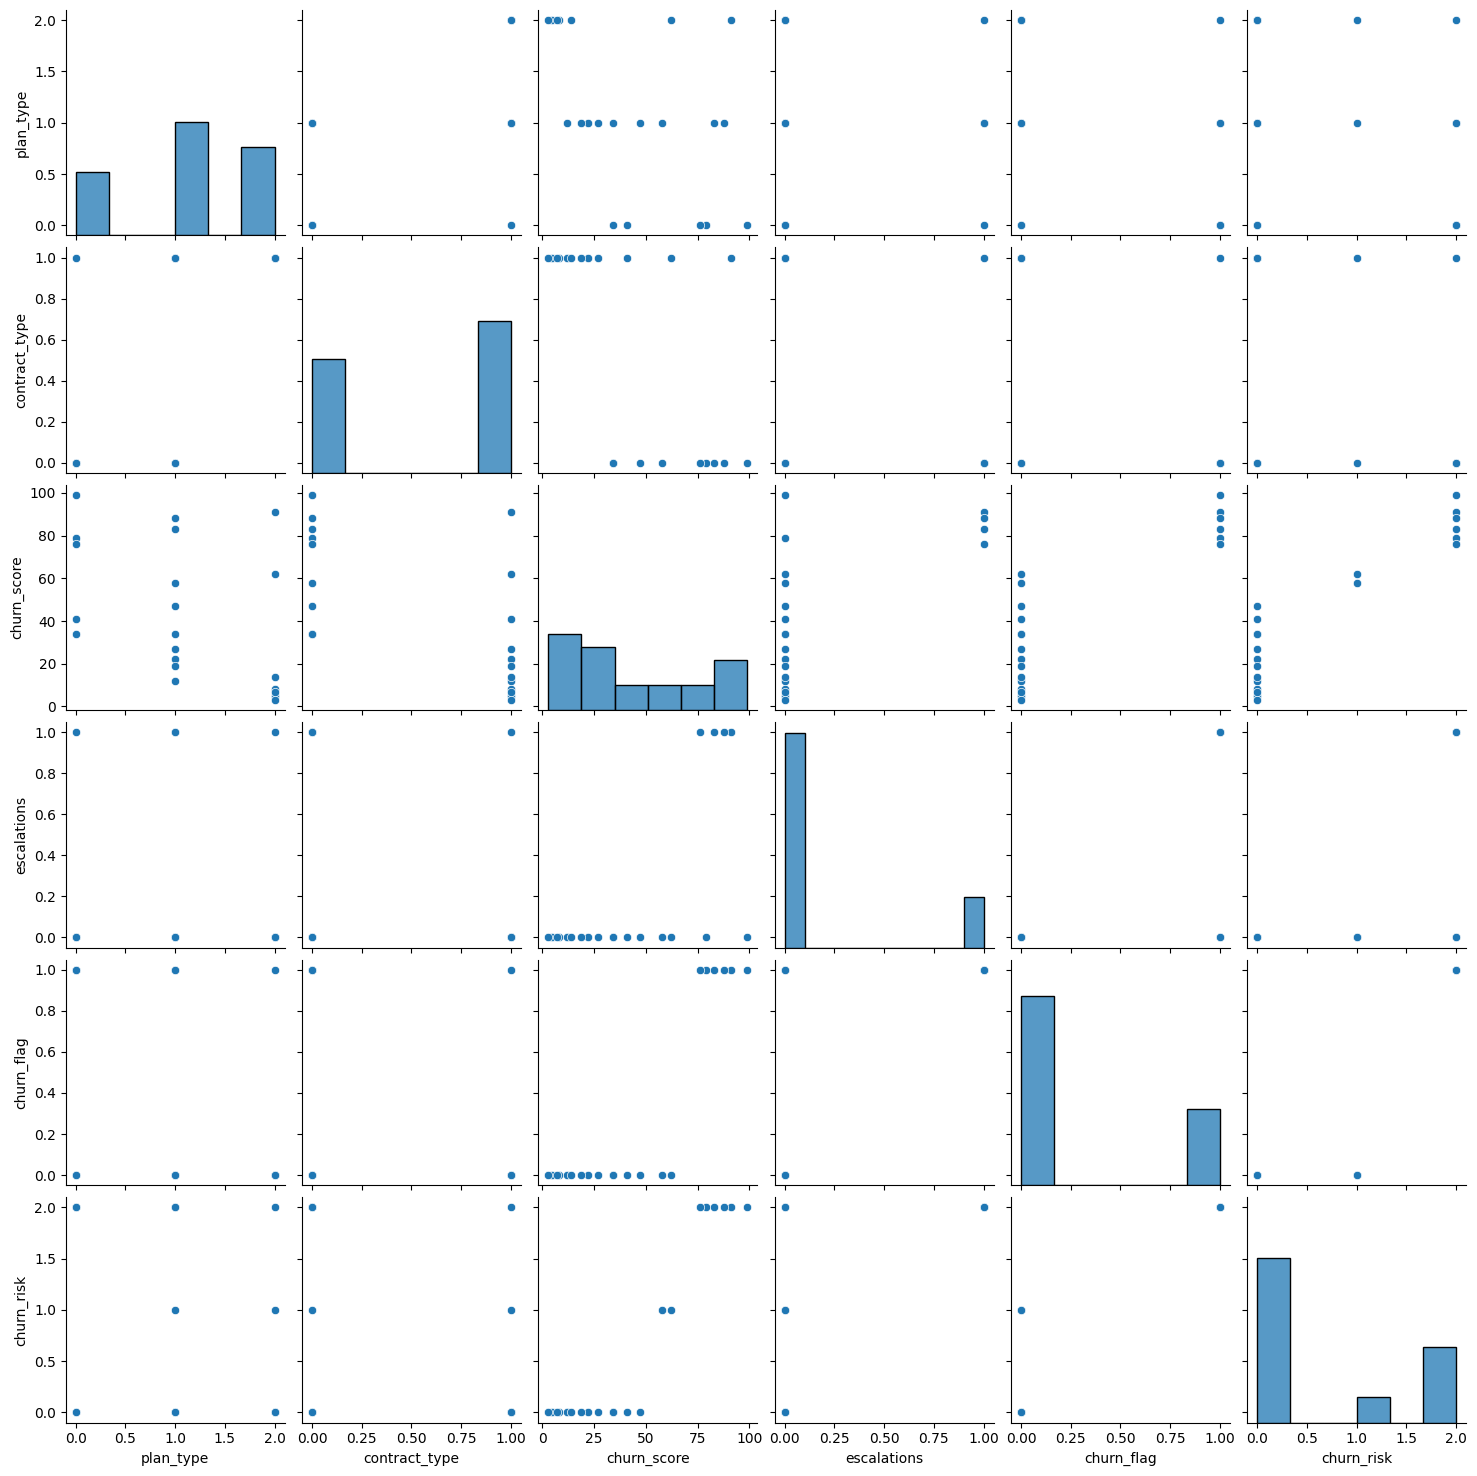

In [88]:
# pair plot - use in relationship in a dataset
sns.pairplot(df_encoded)

In [89]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_Month'],
      dtype='object')

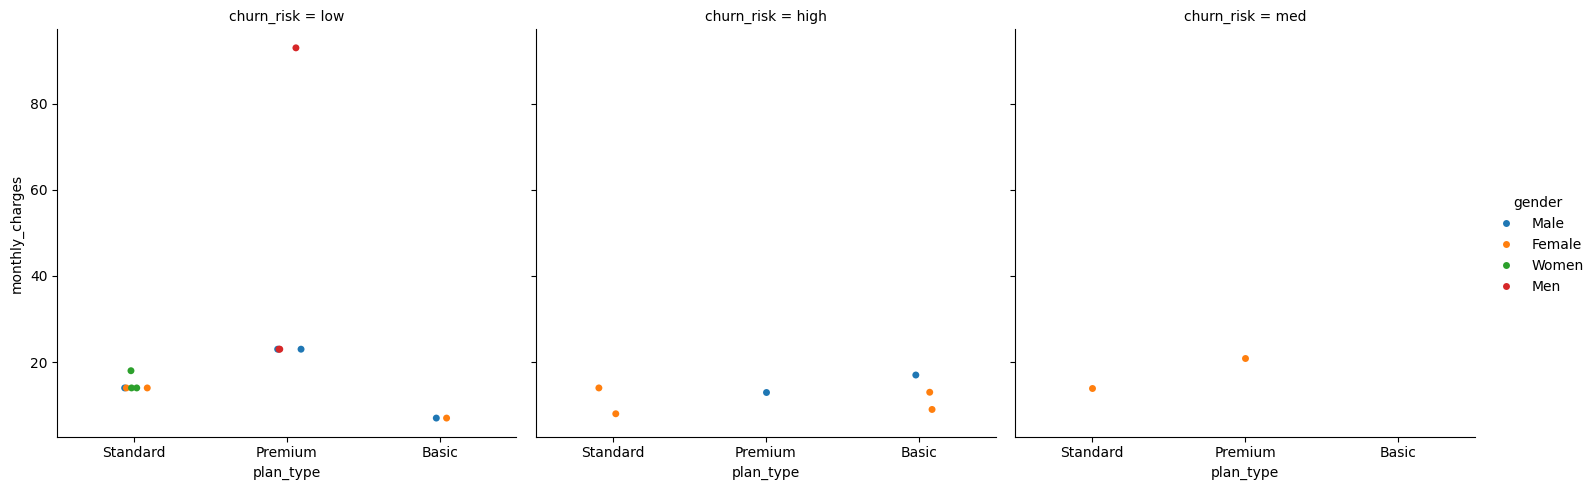

In [90]:
# catplot/facegrid plot - 
# catplot is a Seaborn function used to visualize categorical data.For example, you want to answer: How does churn differ by plan type?
# FacetGrid is used when you want to create multiple small charts, where each chart represents a different category.
#  ex, you want to analyze: Churn by plan type, separated by contract type.


sns.catplot(data = df_visual,
           x= 'plan_type',
           y ='monthly_charges', 
           hue = 'gender',
           col ='churn_risk' )

# pivote table



In [91]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean'

).reset_index()
    

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [92]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_Month'],
      dtype='object')

In [93]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values= ['monthly_charges' , 'customerid','churn_flag'],
    aggfunc = {
        'monthly_charges' :'sum' ,
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)
    

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


# Working with SQL in python (pandas)

In [95]:
pd.read_sql("SELECT * FROM users", conn)

,first_name,country,budget
0,Rahul,India,50000
1,Amit,India,75000
2,John,USA,90000
3,Emma,UK,65000
4,Priya,India,45000
5,David,Canada,80000
6,Sofia,Australia,70000
7,Arjun,India,60000


In [96]:
# inser data 

cursor = conn.cursor()

cursor.execute(
    """
        INSERT INTO users VALUES
        ('Rahul', 'India', 50000),
        ('Amit', 'India', 75000),
        ('John', 'USA', 90000),
        ('Emma', 'UK', 65000),
        ('Priya', 'India', 45000),
        ('David', 'Canada', 80000),
        ('Sofia', 'Australia', 70000),
        ('Arjun', 'India', 60000)
        
    """
)

# commit and save
conn.commit()
print("Data Inserted Successfully!")

Data Inserted Successfully!


In [97]:
# checkd insertec data in table

conn = sqlite3.connect('test_database.sqlite')

query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results



,first_name,country,budget
0,Rahul,India,50000
1,Amit,India,75000
2,John,USA,90000
3,Emma,UK,65000
4,Priya,India,45000
5,David,Canada,80000
6,Sofia,Australia,70000
7,Arjun,India,60000
8,Rahul,India,50000
9,Amit,India,75000


In [98]:
# Aggregation

query = """
SELECT country, SUM(budget) AS total_budget
FROM users
GROUP BY country
"""

df_agg = pd.read_sql(query, conn)

display(df_agg)

,country,total_budget
0,Australia,140000
1,Canada,160000
2,India,460000
3,UK,130000
4,USA,180000
